In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from cdrift import evaluation
from cdrift.utils.helpers import readCSV_Lists, convertToTimedelta, importLog
import numpy as np
from datetime import datetime
from statistics import mean, harmonic_mean, stdev
from scipy.stats import iqr
from typing import List
import seaborn as sns
import re
import os
from pathlib import Path

LAG_WINDOW = 200
MIN_SUPPORT = 1 # Minimum support for latency calculation --> a parameter setting must have at least 3 instances where a true positive was detected before it can be deemed the "best parameter setting" for latency calculation

CSV_PATH = r"additional-log-results\algorithm_results-additionallog-3-bose-maaradji-emd-martjushev-adwin-j.csv"
OUT_PATH = "Evaluation_Results"

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

c:\PA-seminar\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd, re

raw = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
sus_cols = ["Detected Changepoints", "Actual Changepoints for Log"]

for col in sus_cols:
    if col not in raw.columns: 
        continue
    # anything like word(...), e.g., array(...), np.int64(...), Timedelta(...)
    mask = raw[col].str.contains(r"\b[A-Za-z_][A-Za-z0-9_]*\s*\(", na=False)
    bad = raw[mask]
    if not bad.empty:
        print(f"Suspicious '{col}' values (first 5):")
        print(bad[[col]].head())

Suspicious 'Detected Changepoints' values (first 5):
                                Detected Changepoints
38  [np.float64(497.4), np.float64(917.0), np.floa...
39  [np.float64(497.4), np.float64(994.81818181818...
40  [np.float64(497.4), np.float64(994.81818181818...
41  [np.float64(497.4), np.float64(994.81818181818...
42  [np.float64(497.4), np.float64(994.81818181818...


## Preprocessing

In [3]:
df = readCSV_Lists(CSV_PATH)
df.copy()

,Algorithm,Log Source,Log,Complete-Window Size,Detection-Window Size,Stable Period,Detected Changepoints,Actual Changepoints for Log,F1-Score,Average Lag,...,Duration (Seconds),Seconds per Case,P-Value,Min Adaptive Window,Max Adaptive Window,MRID,Epsilon,Window Size,SW Step Size,ADWIN Step Size
0,LCDD,AdditionalLogs,recurring_drift_03,300.0,300.0,200.0,"[301, 631, 962, 1284]","[500, 1000]",0.666667,84.5,...,0.015918,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Process Graph Metrics,AdditionalLogs,gradual_drift_06,NaN,NaN,NaN,"[464, 972]","[500, 1000]",1.000000,32.0,...,16.542502,0.011816,0.005,200.0,600.0,NaN,NaN,NaN,NaN,NaN
2,LCDD,AdditionalLogs,sudden_drift_03,1200.0,1200.0,200.0,[],"[500, 1000]",NaN,NaN,...,0.008164,0.000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LCDD,AdditionalLogs,gradual_drift_03,800.0,800.0,10.0,[830],"[500, 1000]",0.666667,170.0,...,0.004246,0.000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Process Graph Metrics,AdditionalLogs,recurring_drift_04,NaN,NaN,NaN,"[622, 1162]","[500, 1000]",1.000000,142.0,...,2.652046,0.001768,0.100,300.0,500.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,Martjushev ADWIN J,AdditionalLogs,recurring_drift_04,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,25.684836,0.017123,0.400,200.0,500.0,NaN,NaN,NaN,NaN,10.0
4496,Martjushev ADWIN J,AdditionalLogs,sudden_drift_02,NaN,NaN,NaN,[919],"[500, 1000]",0.666667,81.0,...,29.593695,0.019729,0.400,200.0,500.0,NaN,NaN,NaN,NaN,10.0
4497,Martjushev ADWIN J,AdditionalLogs,sudden_drift_02,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,19.375751,0.012917,0.400,200.0,500.0,NaN,NaN,NaN,NaN,50.0
4498,Martjushev ADWIN J,AdditionalLogs,sudden_drift_01,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,19.960862,0.013307,0.400,200.0,500.0,NaN,NaN,NaN,NaN,20.0


### Exclude Martjushev WC (In favor of LCDD)

In [4]:
df = df[df["Algorithm"] != "Martjushev ADWIN WC"]

### Rename approaches to shorter names

In [5]:
print(df["Algorithm"].unique())
shorter_names = {
    "Zheng DBSCAN": "RINV",
    "Maaradji Runs": "ProDrift",
    "Bose J": "J-Measure",
    "Bose WC": "Window Count",
    "Earth Mover's Distance": "EMD",
    "Process Graph Metrics": "PGM",
    "Martjushev ADWIN J": "ADWIN J",
    "Martjushev ADWIN WC": "ADWIN WC",
    "LCDD": "LCDD"
}
df["Algorithm"] = df["Algorithm"].map(shorter_names)
df["Algorithm"].unique()

['LCDD' 'Process Graph Metrics' 'Zheng DBSCAN' 'Bose J' 'Bose WC'
 "Earth Mover's Distance" 'Maaradji Runs' 'Martjushev ADWIN J']


array(['LCDD', 'PGM', 'RINV', 'J-Measure', 'Window Count', 'EMD',
       'ProDrift', 'ADWIN J'], dtype=object)

In [6]:
# Order in which to plot the approaches, to stay consistent
ALPHA_SORT_NAMES = sorted(list(df["Algorithm"].unique()))
ALPHA_SORT_NAMES

['ADWIN J',
 'EMD',
 'J-Measure',
 'LCDD',
 'PGM',
 'ProDrift',
 'RINV',
 'Window Count']

In [7]:
print("Initial shape:", df.shape)
print("Columns:", list(df.columns))

Initial shape: (4500, 21)
Columns: ['Algorithm', 'Log Source', 'Log', 'Complete-Window Size', 'Detection-Window Size', 'Stable Period', 'Detected Changepoints', 'Actual Changepoints for Log', 'F1-Score', 'Average Lag', 'Duration', 'Duration (Seconds)', 'Seconds per Case', 'P-Value', 'Min Adaptive Window', 'Max Adaptive Window', 'MRID', 'Epsilon', 'Window Size', 'SW Step Size', 'ADWIN Step Size']


### Only use Atomic Logs

### Calculate Log Lengths for Scalability

In [8]:
_groupkeys = list(df.groupby(["Log Source", "Log"]).groups.keys())
_logpaths = [Path("EvaluationLogs", source, f"{log}.xes.gz") for source, log in _groupkeys]

loglengths = dict()
loglengths_events = dict()

for logpath in _logpaths:
    log = importLog(logpath.as_posix(), verbose=False)
    loglengths[logpath] = len(log)
    loglengths_events[logpath] = len([evt for case in log for evt in case])

In [9]:
print(f"Number of Logs: {len(loglengths.keys())}")
print(f"Number of Cases: {sum(loglengths.values())}")
print(f"Number of Events: {sum(loglengths_events.values())}")

Number of Logs: 30
Number of Cases: 44000
Number of Events: 736165


##### Number of Drifts

In [10]:
num_drifts = sum(
    len(group.iloc[0]["Actual Changepoints for Log"])
    for name, group in df.groupby(["Log Source", "Log"])
)
print("Total number of drifts:", num_drifts)

Total number of drifts: 60


### Check for Duplicate Rows (Sanity Check)

In [11]:
def split_by_name(df):
    return [
        (alg, df[df["Algorithm"] == alg].copy())
        for alg in df["Algorithm"].unique()
    ]

dfs = split_by_name(df)

if not pd.read_csv(CSV_PATH).duplicated().any():
    print("No duplicate rows in the Dataframe! :)")
else:
    for name, d in split_by_name(pd.read_csv(CSV_PATH)):
        print(f"{name} contains duplicate rows: {d.duplicated().any()}")

df

No duplicate rows in the Dataframe! :)


,Algorithm,Log Source,Log,Complete-Window Size,Detection-Window Size,Stable Period,Detected Changepoints,Actual Changepoints for Log,F1-Score,Average Lag,...,Duration (Seconds),Seconds per Case,P-Value,Min Adaptive Window,Max Adaptive Window,MRID,Epsilon,Window Size,SW Step Size,ADWIN Step Size
0,LCDD,AdditionalLogs,recurring_drift_03,300.0,300.0,200.0,"[301, 631, 962, 1284]","[500, 1000]",0.666667,84.5,...,0.015918,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PGM,AdditionalLogs,gradual_drift_06,NaN,NaN,NaN,"[464, 972]","[500, 1000]",1.000000,32.0,...,16.542502,0.011816,0.005,200.0,600.0,NaN,NaN,NaN,NaN,NaN
2,LCDD,AdditionalLogs,sudden_drift_03,1200.0,1200.0,200.0,[],"[500, 1000]",NaN,NaN,...,0.008164,0.000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LCDD,AdditionalLogs,gradual_drift_03,800.0,800.0,10.0,[830],"[500, 1000]",0.666667,170.0,...,0.004246,0.000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PGM,AdditionalLogs,recurring_drift_04,NaN,NaN,NaN,"[622, 1162]","[500, 1000]",1.000000,142.0,...,2.652046,0.001768,0.100,300.0,500.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,ADWIN J,AdditionalLogs,recurring_drift_04,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,25.684836,0.017123,0.400,200.0,500.0,NaN,NaN,NaN,NaN,10.0
4496,ADWIN J,AdditionalLogs,sudden_drift_02,NaN,NaN,NaN,[919],"[500, 1000]",0.666667,81.0,...,29.593695,0.019729,0.400,200.0,500.0,NaN,NaN,NaN,NaN,10.0
4497,ADWIN J,AdditionalLogs,sudden_drift_02,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,19.375751,0.012917,0.400,200.0,500.0,NaN,NaN,NaN,NaN,50.0
4498,ADWIN J,AdditionalLogs,sudden_drift_01,NaN,NaN,NaN,[],"[500, 1000]",NaN,NaN,...,19.960862,0.013307,0.400,200.0,500.0,NaN,NaN,NaN,NaN,20.0


### Define Color Schema

In [15]:
colors = ["#DB444B","#9A607F","#006BA2","#3EBCD2","#379A8B","#EBB434","#B4BA39","#D1B07C"]
color_map = {ALPHA_SORT_NAMES[i]:colors[i] for i in range(0,len(ALPHA_SORT_NAMES))}

## Accuracy
- All Change-Patterns
- Only 0 Noise
- Max cummulative *Recall* achieved of all parameter settings
  - Accumulate TP and FP over all event logs before calculating recall

In [16]:
df["Algorithm"].unique()

array(['LCDD', 'PGM', 'RINV', 'J-Measure', 'Window Count', 'EMD',
       'ProDrift', 'ADWIN J'], dtype=object)

In [17]:
used_parameters = {
    "J-Measure": ["Window Size", "SW Step Size"],
    "Window Count": ["Window Size", "SW Step Size"],
    "ADWIN J": ["Min Adaptive Window", "Max Adaptive Window", "P-Value", "ADWIN Step Size"],
    "ADWIN WC": ["Min Adaptive Window", "Max Adaptive Window", "P-Value", "ADWIN Step Size"],
    "ProDrift": ["Window Size", "SW Step Size"],
    "EMD": ["Window Size", "SW Step Size"],
    "PGM": ["Min Adaptive Window", "Max Adaptive Window", "P-Value"],
    "RINV": ["MRID", "Epsilon"],
    "LCDD": ["Complete-Window Size", "Detection-Window Size", "Stable Period"],
}


def calcAccuracy(df:pd.DataFrame, param_names:List[str], lag_window: int):
    """Calculates the Accuracy Metric for the given dataframe by grouping by the given parameters and calculating the mean accuracy

    Args:
        df (pd.DataFrame): The dataframe containing the results to be evaluated
        param_names (List[str]): The names of the parameters of this approach
        lag_window (int): The lag window to be used for the evaluation to determine true positives and false positives

    Returns:
        _type_: _description_
    """

    f1s = dict()
    recalls = dict()
    precisions = dict()
    # Group by parameter values to calculate accuracy per parameter setting, over all logs
    for parameters, group in df.groupby(by=param_names):
        # Calculate Accuracy for this parameter setting
        ## --> F1-Score, but first collect all TP and FP
        tps = 0
        fps = 0
        positives = 0
        detected = 0

        # Collect TP FP, etc. 
        for index, row in group.iterrows():
            actual_cp = row["Actual Changepoints for Log"]
            detected_cp = row["Detected Changepoints"]
            tp, fp = evaluation.getTP_FP(detected_cp, actual_cp, lag_window)
            tps += tp
            fps += fp
            positives += len(actual_cp)
            detected += len(detected_cp)

        try:
            precisions[parameters] = tps / detected
        except ZeroDivisionError:
            precisions[parameters] = np.nan
        
        try:
            recalls[parameters] = tps / positives
        except ZeroDivisionError:
            recalls[parameters] = np.nan

        f1s[parameters] = harmonic_mean([precisions[parameters], recalls[parameters]]) # If either is nan, the harmonic mean is nan
    return (precisions, recalls, f1s)

def calculate_accuracy_metric_df(dataframe, lag_window, verbose=True):
    computed_accuracy_dicts = dict()
    computed_precision_dicts = dict()
    computed_recall_dicts = dict()

    accuracy_best_param = dict()

    accuracies = dict()
    for name, a_df in dataframe.groupby(by="Algorithm"):
        computed_precision_dicts[name], computed_recall_dicts[name], computed_accuracy_dicts[name] = calcAccuracy(a_df, used_parameters[name], lag_window)

        best_param = max(computed_accuracy_dicts[name],  key=lambda x: computed_accuracy_dicts[name][x])

        accuracy_best_param[name] = best_param

        # accuracies[name] = max(computed_accuracy_dicts[name].values())
        accuracies[name] = computed_accuracy_dicts[name][best_param]
        if verbose:
            print(f"{name}: {accuracies[name]}")

    return (accuracies, computed_accuracy_dicts, computed_precision_dicts, computed_recall_dicts, accuracy_best_param)

accuracies, computed_accuracy_dicts, computed_precision_dicts, computed_recall_dicts, accuracy_best_param = calculate_accuracy_metric_df(df, LAG_WINDOW, verbose=False)

pd.DataFrame([{'Algorithm': name, 'Accuracy': accuracies[name]} for name in accuracies.keys()]).sort_values(by="Algorithm", ascending=True)

,Algorithm,Accuracy
0,ADWIN J,0.095238
1,EMD,0.606742
2,J-Measure,0.846154
3,LCDD,0.857143
4,PGM,0.888889
5,ProDrift,0.554217
6,RINV,0.613497
7,Window Count,0.571429


#### Plot Accuracy as Barplot of Precision, Recall, F1

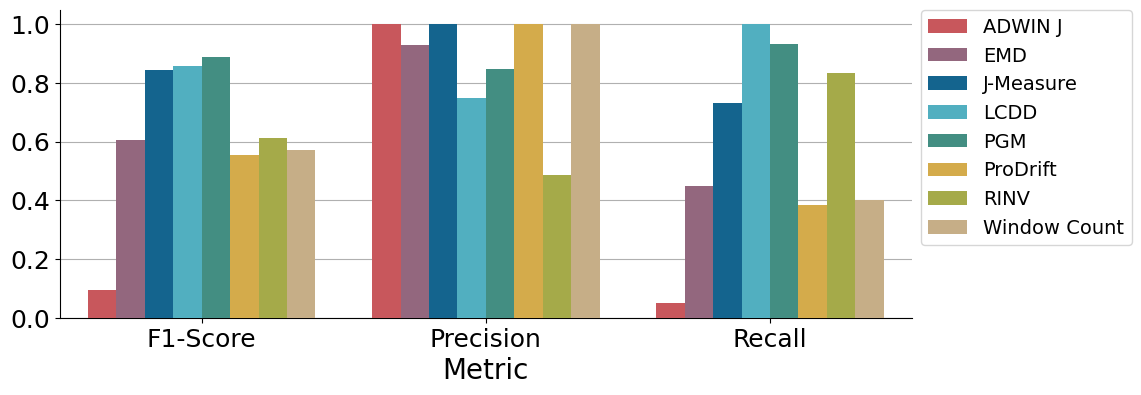

In [18]:

accuracy_plot_df = pd.DataFrame(
    [
        {
            "Algorithm": name,
            "Metric": "F1-Score",
            "Value": computed_accuracy_dicts[name][accuracy_best_param[name]]
        }
        for name in computed_accuracy_dicts.keys()
    ] + [
        {
            "Algorithm": name,
            "Metric": "Precision",
            "Value": computed_precision_dicts[name][accuracy_best_param[name]]
        }
        for name in computed_accuracy_dicts.keys()
    ] + [
        {
            "Algorithm": name,
            "Metric": "Recall",
            "Value": computed_recall_dicts[name][accuracy_best_param[name]]
        }
        for name in computed_accuracy_dicts.keys()
    ]
)

palette=None #{"Precision": "#573deb", "F1-Score": "#ff0076", "Recall": "#ffa600"}
palette = sns.color_palette(colors)
plt.grid(zorder=0)
ax = sns.barplot(x="Metric", y="Value", data=accuracy_plot_df, hue="Algorithm", palette=palette, hue_order=ALPHA_SORT_NAMES,zorder =5)

ax.figure.set_size_inches(11, 4)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=18)
ax.set_xlabel(ax.get_xlabel(), size = 20)
ax.set_ylabel("", size = 20)
#ax.get_yaxis().set_visible(False)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,prop={'size': 14})

if not os.path.exists(f"{OUT_PATH}/Accuracy{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Accuracy{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Accuracy{LAG_WINDOW}/accuracy_c.pdf", bbox_inches="tight", format="pdf")
plt.show()

### Plot as Points

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\295339132.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  ax = sns.pointplot(


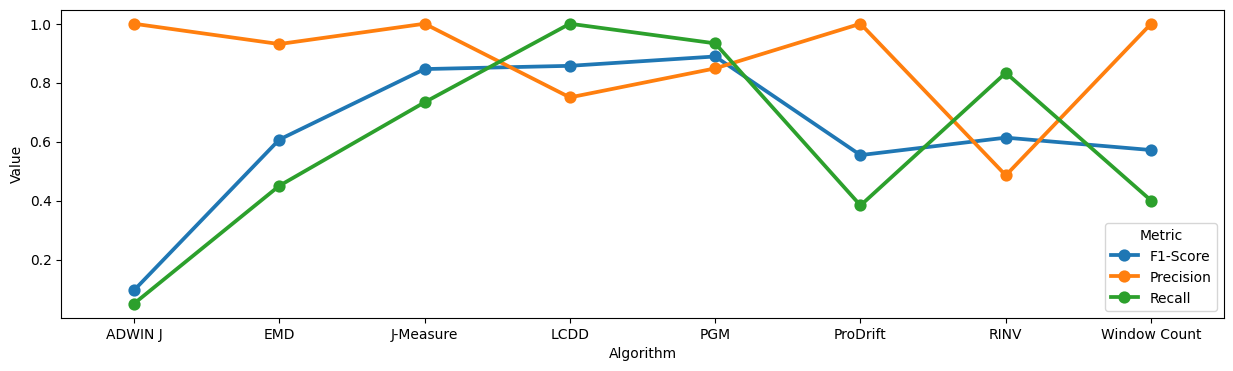

In [19]:
ax = sns.pointplot(
    x="Algorithm",
    y="Value",
    data=accuracy_plot_df,
    hue="Metric",
    order=ALPHA_SORT_NAMES,
    join=True,
)
ax.figure.set_size_inches(15, 4)
plt.show()

## Latency
- Using best parameter setting
- Same logs as above

In [20]:
from statistics import mean

def calcLatencies(df, param_names, lag_window):
    latencies = dict()
    for parameters, group in df.groupby(by=param_names):
        lags = []
        for index, row in group.iterrows():
            actual_cp = row["Actual Changepoints for Log"]
            detected_cp = row["Detected Changepoints"]
            assignments = evaluation.assign_changepoints(detected_cp, actual_cp, lag_window)
            for d, a in assignments:
                lags.append(abs(d-a))
        latencies[parameters] = lags
    return latencies

def calculate_latency(dataframe, lag_window, min_support=1, verbose=True):
    latencies = dict() # Dict holding the best achieved latency per approach
    scaled_latency_dicts = dict() # Dict holding the scaled mean latency per approach per parameter setting
    computed_latency_dicts = dict() # Dict holding the raw list of detection lags per approach per parameter setting
    best_params_latency = dict() # Dict holding the best parameter setting per approach (the one that achieves the best latency)
    for name, a_df in dataframe.groupby(by="Algorithm"):
        result = calcLatencies(a_df, used_parameters[name], lag_window)
        computed_latency_dicts[name] = result
        latency_scaled_dict = {
            param: 1-(mean(result[param])/lag_window) if len(result[param]) >= min_support else np.nan
            for param in result.keys()
        }
        scaled_latency_dicts[name] = latency_scaled_dict
        best_param = max(latency_scaled_dict,  key=lambda x: latency_scaled_dict[x] if not np.isnan(latency_scaled_dict[x]) else -1)

        best_params_latency[name] = best_param
        latencies[name] = latency_scaled_dict[best_param]

        if verbose:
            print(f"{name}: {(1-latencies[name])*lag_window} Traces; Score: {latencies[name]}")
    return (latencies, scaled_latency_dicts, computed_latency_dicts, best_params_latency)

latencies, scaled_latency_dicts, computed_latency_dicts, best_params_latency = calculate_latency(df, LAG_WINDOW, min_support=MIN_SUPPORT, verbose=False)

pd.DataFrame([{'Algorithm': name, 'Lag (Traces)': (1-latencies[name])*LAG_WINDOW, 'Lag (Score)': latencies[name]} for name in latencies.keys()]).sort_values(by="Algorithm", ascending=True)

,Algorithm,Lag (Traces),Lag (Score)
0,ADWIN J,51.000000,0.745000
1,EMD,31.111111,0.844444
2,J-Measure,36.363636,0.818182
3,LCDD,24.500000,0.877500
4,PGM,60.017857,0.699911
5,ProDrift,30.782609,0.846087
6,RINV,33.430535,0.832847
7,Window Count,46.000000,0.770000


#### Plot Latency
- Plotting the observed average latency along with the corresponding standard deviation for the found best parameter setting

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\501791855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Algorithm", y="Unscaled Latency", data=latency_plot_df,palette= palette, order=ALPHA_SORT_NAMES)


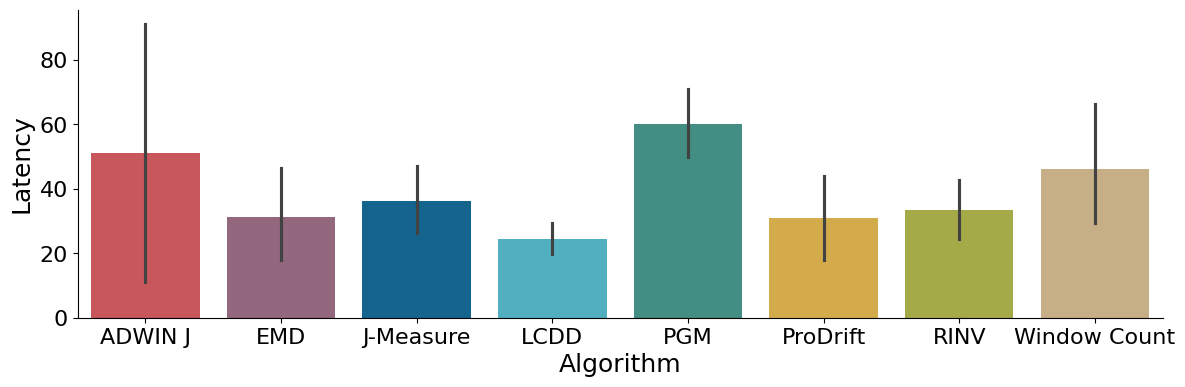

In [21]:
latency_plot_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Unscaled Latency": latency
    }
    for name in computed_latency_dicts.keys()
    for latency in computed_latency_dicts[name][best_params_latency[name]]
])

ax = plt.subplots(figsize=(17, 4))

# Order by latency, ascending (best is left)
# order = [name for name, _ in sorted(latencies.items(), key=lambda x: x[1] if not np.isnan(x[1]) else 0, reverse=True)]
# print(order)
ax = sns.barplot(x="Algorithm", y="Unscaled Latency", data=latency_plot_df,palette= palette, order=ALPHA_SORT_NAMES)
plt.ylabel("Latency")# [Traces]")
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel(ax.get_xlabel(), size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)
ax.figure.set_size_inches(14, 4)

if not os.path.exists(f"{OUT_PATH}/Latency{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Latency{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Latency{LAG_WINDOW}/latency.pdf", bbox_inches="tight", format="pdf")
plt.show()


## Scalability
- Mean Duration
- Across ***all*** logs this time!

In [29]:
scalabilities = dict()
for name, a_df in df.groupby("Algorithm"):
    result = a_df["Duration (Seconds)"].mean()
    result_str = datetime.strftime(datetime.utcfromtimestamp(result), '%H:%M:%S')
    scalabilities[name] = {"avg_seconds": result, "str": result_str}

pd.DataFrame([{'Algorithm': name, 'Scalability': scalabilities[name]["str"], 'Average Seconds': scalabilities[name]['avg_seconds']} for name in scalabilities.keys()]).sort_values(by="Algorithm", ascending=True)

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\878668481.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  result_str = datetime.strftime(datetime.utcfromtimestamp(result), '%H:%M:%S')


,Algorithm,Scalability,Average Seconds
0,ADWIN J,00:00:22,22.879298
1,EMD,00:00:31,31.281480
2,J-Measure,00:02:26,146.752933
3,LCDD,00:00:00,0.032038
4,PGM,00:00:03,3.716807
5,ProDrift,00:02:01,121.236911
6,RINV,00:00:00,0.456683
7,Window Count,00:02:13,133.548209


#### Plot Boxplot of Mean Absolute Duration

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\2114683517.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


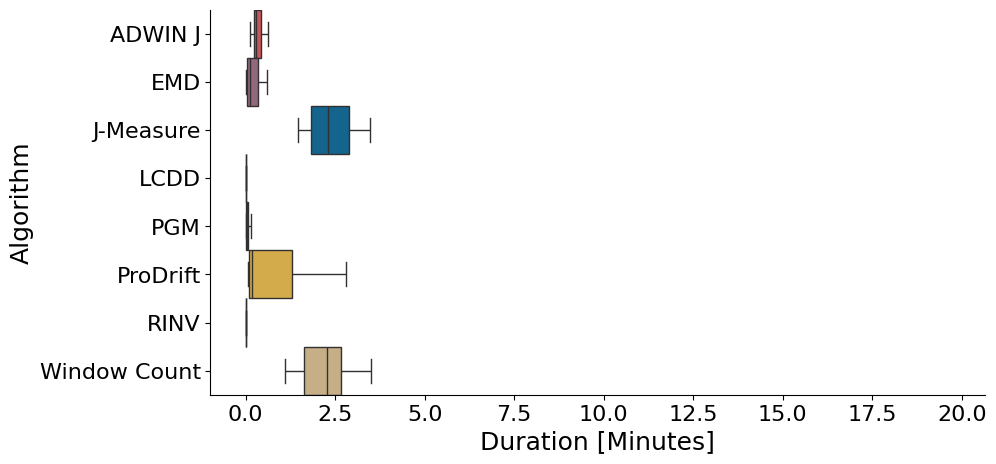

In [30]:
scalability_plot_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Duration": duration / 60
    }
    for name, a_df in dfs
    for duration in a_df["Duration (Seconds)"].tolist()
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Duration [Minutes]")

sorted_names = list(scalabilities.items())
sorted_names.sort(key=lambda x: x[1]["avg_seconds"])

ax = sns.boxplot(
    data=scalability_plot_df,
    order=ALPHA_SORT_NAMES,#[name for name, _ in sorted_names] if False else None, # Disable sorting for now, maybe this means that the order is the same in every plot
    x="Duration",
    y="Algorithm",
    palette = palette,
    width=1,
    ax=ax,
    fliersize=0
)
#ax.figure.set_size_inches(14, 4)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel(ax.get_xlabel(), size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)
plt.xlabel("Duration [Minutes]")

if not os.path.exists(f"{OUT_PATH}/Scalability{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Scalability{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Scalability{LAG_WINDOW}/scalability.pdf", bbox_inches="tight", format="pdf")
plt.show()

#### Plot as Barplot as well

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\824548133.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Algorithm", y="Duration", data=scalability_barplot_df,palette = palette, order=ALPHA_SORT_NAMES)


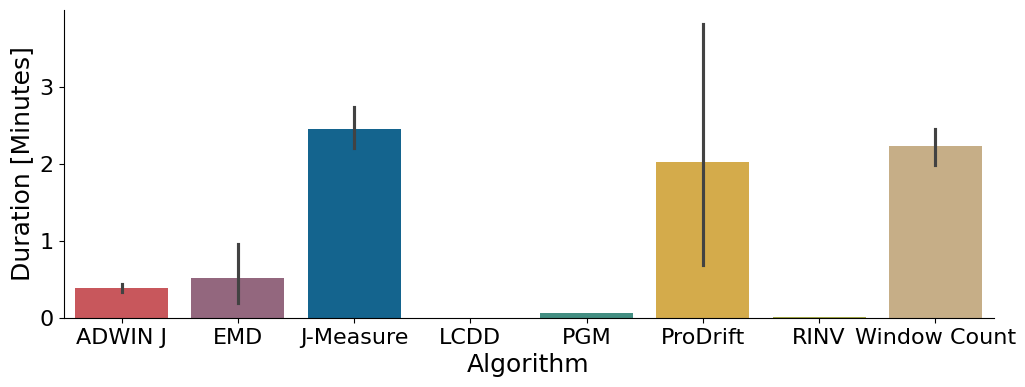

In [31]:
scalability_barplot_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Duration": duration / 60
    }
    for name, a_df in dfs
    for duration in a_df["Duration (Seconds)"].tolist()
])

ax = plt.subplots(figsize=(17, 4))

# Order by latency, ascending (best is left)
# order = [name for name, _ in sorted(latencies.items(), key=lambda x: x[1] if not np.isnan(x[1]) else 0, reverse=True)]
# print(order)

ax = sns.barplot(x="Algorithm", y="Duration", data=scalability_barplot_df,palette = palette, order=ALPHA_SORT_NAMES)
ax.figure.set_size_inches(12, 4)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel(ax.get_xlabel(), size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)
plt.ylabel("Duration [Minutes]")
plt.savefig(f"{OUT_PATH}/Scalability{LAG_WINDOW}/scalability_barplot.pdf", bbox_inches="tight", format="pdf")
plt.show()

## Seconds per Case/Event

In [32]:
df_seconds = df.copy()
# Add Log Length Column
df_seconds["Log Length (Cases)"] = df_seconds[["Log Source", "Log"]].apply(axis=1, func=lambda x: loglengths[Path("EvaluationLogs", x[0], x[1]+".xes.gz")])
df_seconds["Log Length (Events)"] = df_seconds[["Log Source", "Log"]].apply(axis=1, func=lambda x: loglengths_events[Path("EvaluationLogs", x[0], x[1]+".xes.gz")])

seconds_per_case = dict()
seconds_per_event = dict()

for name, group in df_seconds.groupby("Algorithm"):
    total_seconds = group["Duration (Seconds)"].sum()

    total_cases = group["Log Length (Cases)"].sum()
    total_events = group["Log Length (Events)"].sum()

    seconds_per_case[name] = total_seconds / total_cases
    seconds_per_event[name] = total_seconds / total_events

pd.DataFrame([{'Algorithm': name, 'Seconds per Case': seconds_per_case[name], 'Seconds per Event': seconds_per_event[name]} for name in seconds_per_case.keys()]).sort_values(by="Algorithm", ascending=True)

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\1185191031.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_seconds["Log Length (Cases)"] = df_seconds[["Log Source", "Log"]].apply(axis=1, func=lambda x: loglengths[Path("EvaluationLogs", x[0], x[1]+".xes.gz")])
C:\Users\laury\AppData\Local\Temp\ipykernel_1952\1185191031.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_seconds["Log Length (Events)"] = df_seconds[["Log Source", "Log"]].apply(axis=1, func=lambda x: loglengths_events[Path("EvaluationLogs", x[0], x[1]+".xes.gz")])


,Algorithm,Seconds per Case,Seconds per Event
0,ADWIN J,0.015600,0.000932
1,EMD,0.021328,0.001275
2,J-Measure,0.100059,0.005980
3,LCDD,0.000022,0.000001
4,PGM,0.002534,0.000151
5,ProDrift,0.082662,0.004941
6,RINV,0.000311,0.000019
7,Window Count,0.091056,0.005442


In [33]:
df_seconds["Milliseconds per Event"] = df_seconds.apply(lambda x: (x["Duration (Seconds)"]*1000) / x["Log Length (Events)"], axis=1)
df_seconds[["Duration (Seconds)", "Log Length (Events)", "Milliseconds per Event"]].head()

,Duration (Seconds),Log Length (Events),Milliseconds per Event
0,0.015918,9433,0.001688
1,16.542502,90749,0.182289
2,0.008164,9355,0.000873
3,0.004246,8704,0.000488
4,2.652046,9752,0.271949


### Plot Boxplot and Barplot of milliseconds per event

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\808963279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


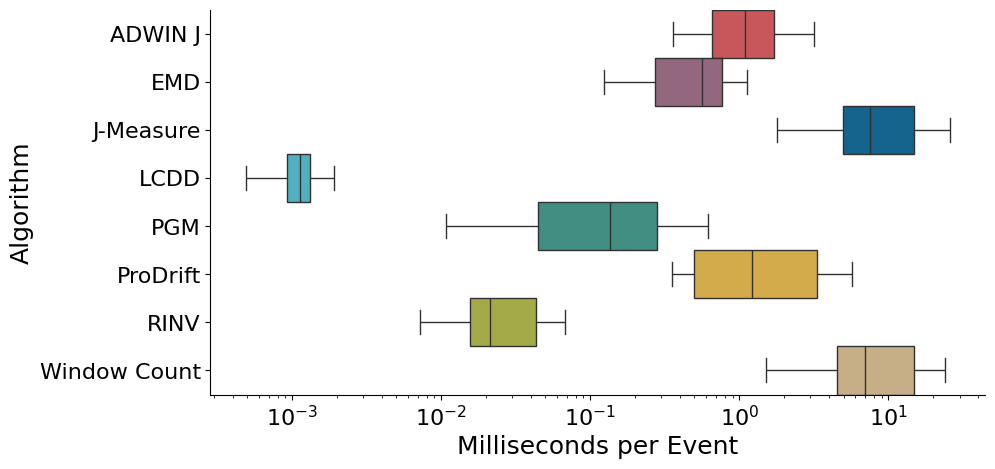

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Milliseconds per Event")


ax = sns.boxplot(
    data=df_seconds,
    order=ALPHA_SORT_NAMES,
    x="Milliseconds per Event",
    y="Algorithm",
    palette = palette,
    width=1,
    ax=ax,
    fliersize=0

)

ax.set_xscale("log")

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel(ax.get_xlabel(), size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)
plt.xlabel("Milliseconds per Event")

if not os.path.exists(f"{OUT_PATH}/Scalability{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Scalability{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Scalability{LAG_WINDOW}/scalability_mseconds_per_event.pdf", bbox_inches="tight", format="pdf")
plt.show()

C:\Users\laury\AppData\Local\Temp\ipykernel_1952\2255514799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Algorithm", y="Milliseconds per Event", data=df_seconds, palette = palette, order=ALPHA_SORT_NAMES)


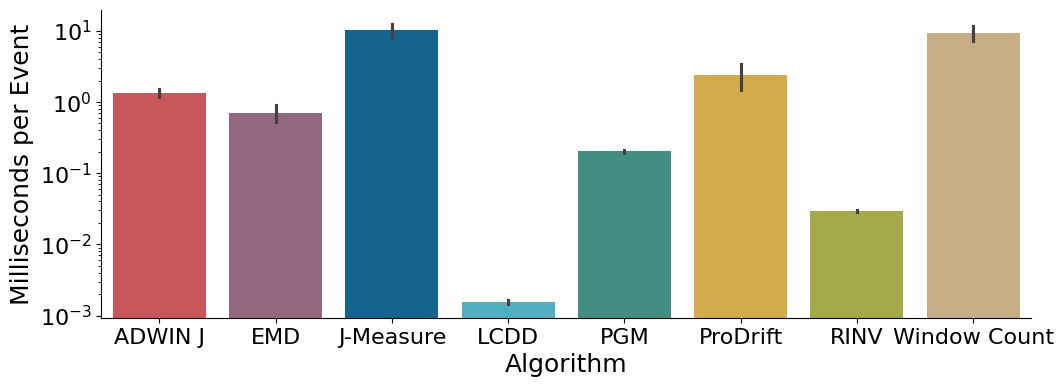

In [35]:
ax = plt.subplots(figsize=(17, 4))

ax = sns.barplot(x="Algorithm", y="Milliseconds per Event", data=df_seconds, palette = palette, order=ALPHA_SORT_NAMES)
ax.figure.set_size_inches(12, 4)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel(ax.get_xlabel(), size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)
ax.set_yscale("log")
plt.ylabel("Milliseconds per Event")

if not os.path.exists(f"{OUT_PATH}/Scalability{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Scalability{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Scalability{LAG_WINDOW}/scalability_mseconds_per_event_barplot.pdf", bbox_inches="tight", format="pdf")
plt.show()

## Parameter Sensitivity
- For each Parameter setting, harmonic mean of *accuracy*, *latency*, and *versatility*
  - &rarr; Visualize the variance, etc., with a boxplot
- Only noiseless logs again

In [36]:

sensitivities = dict()
for name in df["Algorithm"].unique():
    _sensitivities = dict()
    acc = computed_accuracy_dicts[name]
    lat = scaled_latency_dicts[name]
    for param_choice in acc.keys():
        sensitivity = harmonic_mean([acc[param_choice], lat[param_choice]])
        _sensitivities[param_choice] = sensitivity
    sensitivities[name] = _sensitivities


C:\Users\laury\AppData\Local\Temp\ipykernel_1952\765449935.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


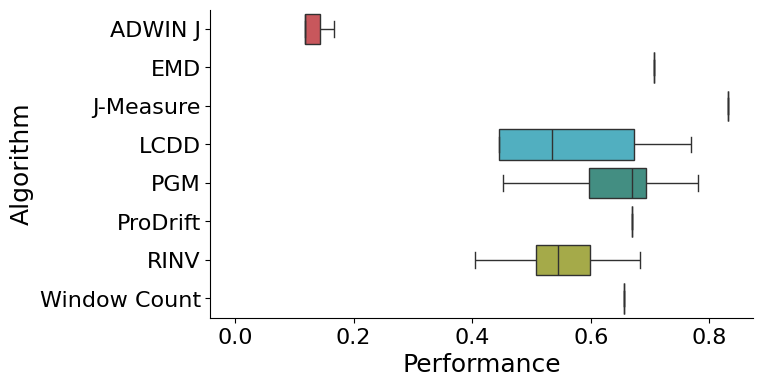

In [37]:
sens_df = pd.DataFrame([
    {
        "Parameters": param,
        "Algorithm": name,
        "Sensitivity Score": sens
    }
    for name, sens_dict in sensitivities.items()
    for param, sens in sens_dict.items()
])
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.boxplot(
    data=sens_df,
    x="Sensitivity Score",
    y="Algorithm",
    palette = palette,
    ax=ax,
    fliersize=0,
    order=ALPHA_SORT_NAMES
)
ax.figure.set_size_inches(7, 4)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.tick_params(labelsize=16)
ax.set_xlabel("Performance", size = 18)
ax.set_ylabel(ax.get_ylabel(), size = 18)

if not os.path.exists(f"{OUT_PATH}/Parameter_Sensitivity{LAG_WINDOW}"):
    os.makedirs(f"{OUT_PATH}/Parameter_Sensitivity{LAG_WINDOW}")
plt.savefig(f"{OUT_PATH}/Parameter_Sensitivity{LAG_WINDOW}/param_sensitivity.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [38]:
# Inter Quartile Range
sensitivity_iqrs = dict()
for name, sens in sensitivities.items():
    _iqr = iqr(list(sens.values()), nan_policy="omit")
    sensitivity_iqrs[name] = _iqr

pd.DataFrame([{'Algorithm': name, 'Inner-Quartile Range': sensitivity_iqrs[name]} for name in sensitivity_iqrs.keys()]).sort_values(by="Algorithm", ascending=True)

,Algorithm,Inner-Quartile Range
7,ADWIN J,0.023880
5,EMD,0.000000
3,J-Measure,0.000000
0,LCDD,0.228441
1,PGM,0.096928
6,ProDrift,0.000000
2,RINV,0.090857
4,Window Count,0.000000


## Save Results

In [46]:
results_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Accuracy": accuracies[name],
        "Latency": (1-latencies[name])*LAG_WINDOW,
        "Scalability": scalabilities[name]["str"],
        "Milliseconds per Case": seconds_per_case[name]*1000,
        "Milliseconds per Event": seconds_per_event[name]*1000,
        "Parameter Sensitivity (IQR)": sensitivity_iqrs[name],
    }
    for name in df["Algorithm"].unique()
])

results_df.to_csv(f"{OUT_PATH}/evaluation_measures{LAG_WINDOW}.csv", index=False)
results_df

,Algorithm,Accuracy,Latency,Scalability,Milliseconds per Case,Milliseconds per Event,Parameter Sensitivity (IQR)
0,LCDD,0.857143,24.500000,00:00:00,0.021844,0.001306,0.228441
1,PGM,0.888889,60.017857,00:00:03,2.534187,0.151466,0.096928
2,RINV,0.613497,33.430535,00:00:00,0.311375,0.018611,0.090857
3,J-Measure,0.846154,36.363636,00:02:26,100.058818,5.980436,0.000000
4,Window Count,0.571429,46.000000,00:02:13,91.055597,5.442321,0.000000
5,EMD,0.606742,31.111111,00:00:31,21.328282,1.274775,0.000000
6,ProDrift,0.554217,30.782609,00:02:01,82.661530,4.940614,0.000000
7,ADWIN J,0.095238,51.000000,00:00:22,15.599521,0.932371,0.023880
